# Xi Line Chart

Plot total `xi` for all countries as thin transparent gray lines, with optional highlighted countries in thicker color.

In [13]:
from pathlib import Path
import os
import sys
import importlib

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from io_networks.config import load_config
import io_networks.viz_xi as viz_xi
importlib.reload(viz_xi)

load_xi_data = viz_xi.load_xi_data
plot_xi_country_lines = viz_xi.plot_xi_country_lines

import matplotlib.pyplot as plt

In [14]:
cfg = load_config('config/default.yaml')
variant = None  # None -> inferred from config (regular/extended)
metric = 'xi'
yscale = 'log'  # linear, log, or symlog
highlight_countries = ['USA', 'CHN', 'DEU', 'JPN', 'IND']
exclude_countries = []  # optional: hide outliers from main panel
label_pad_years = 1.2  # reserve right-side space for direct end labels

In [15]:
df = load_xi_data(cfg=cfg, variant=variant)
print('rows:', len(df))
print('years:', int(df['year'].min()), 'to', int(df['year'].max()))
if 'status' in df.columns:
    print('status counts:', df['status'].value_counts(dropna=False).to_dict())
print(df[['year', 'country', 'xi', 'status']].head(10).to_string(index=False))

rows: 2268
years: 1995 to 2022
status counts: {'ok': 2268}
 year country       xi status
 1995     AGO 0.013725     ok
 1995     ARE 0.046290     ok
 1995     ARG 0.035071     ok
 1995     AUS 0.009801     ok
 1995     AUT 0.016373     ok
 1995     BEL 0.025783     ok
 1995     BGD 0.014772     ok
 1995     BGR 0.019547     ok
 1995     BLR 0.068933     ok
 1995     BRA 0.063742     ok


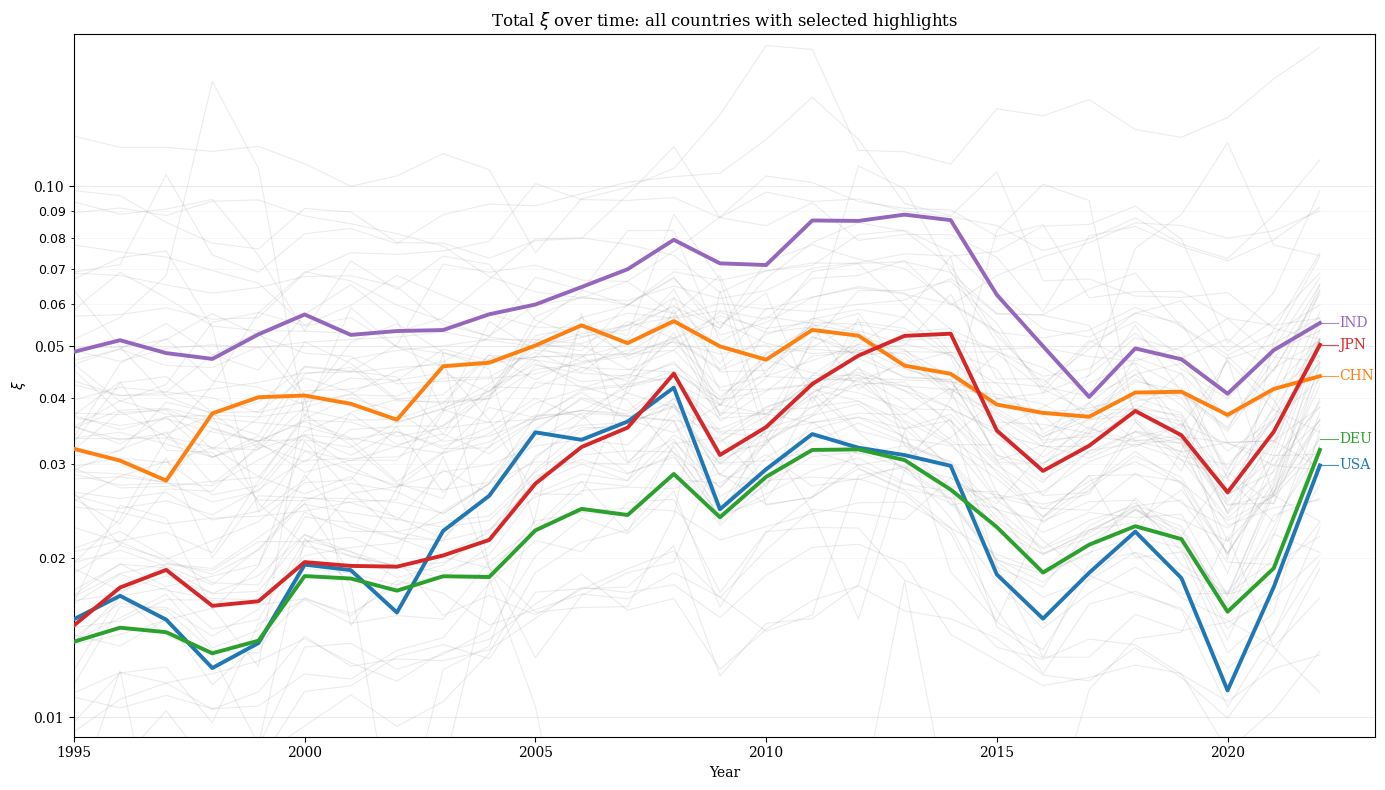

In [16]:
fig, ax = plt.subplots(figsize=(14, 8))
plot_xi_country_lines(
    df,
    metric=metric,
    highlight_countries=highlight_countries,
    exclude_countries=exclude_countries,
    only_ok=True,
    yscale=yscale,
    title=r'Total $\xi$ over time: all countries with selected highlights',
    alpha_bg=0.15,
    lw_bg=0.8,
    lw_hi=2.8,
    use_end_labels=True,
    show_legend=False,
    label_pad_years=label_pad_years,
    ax=ax,
)
plt.tight_layout()
plt.show()

## Try Different Inputs

- Change `highlight_countries` to focus the story.
- Keep `metric='xi'` for total xi first.
- Set `only_ok=False` only if you want to inspect incomplete rows.